Part A - Q2. Use the python urllib library to extract the KDD Cup 99 data from their web repository, store it in a temporary location and then move it to the Databricks filesystem which can enable easy access to this data for analysis.

In [0]:
import urllib.request

urllib.request.urlretrieve("http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz", "/tmp/kddcup_data.gz")
dbutils.fs.mv("file:/tmp/kddcup_data.gz", "dbfs:/kdd/kddcup_data.gz")
display(dbutils.fs.ls("dbfs:/kdd"))

path,name,size,modificationTime
dbfs:/kdd/kddcup_data.gz,kddcup_data.gz,2144903,1720386148000


Part A - Q3. After storing the data in the Databricks filesystem. Load your data from the disk into Spark's RDD. Print 10 values of your RDD and verify the type of data structure of your data

In [0]:
target_file = "dbfs:/kdd/kddcup_data.gz"

# Step 1: Load the data
rdd = spark.sparkContext.textFile(target_file)

# Step 2: Print 10 values from the RDD
sample_data = rdd.take(10)
for line in sample_data:
    print(line)

# Step 3: Verify the type of the RDD
print("-----------------------------------------")
print(f"The data structure is of type: {type(rdd)}")

0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,9,9,1.00,0.00,0.11,0.00,0.00,0.00,0.00,0.00,normal.
0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,19,19,1.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,normal.
0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.00,0.00,1.00,0.00,0.00,29,29,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.
0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,39,39,1.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,normal.
0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,49,49,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.
0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.00,0.00,1.00,0.00,0.00,59,59,1.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,normal.
0,tcp,http,SF,212,1940,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,0.00,0.00,0.00,0.00,1.00,0.00,1.00,1,69,1.00,0.00,1.00,0

Part A - Q4. Split the data. (Each entry in your RDD is a comma-separated line of data, which you first need to split before you can parse and build your data frame.) Show the total number of features (columns) and print results.

In [0]:
split_rdd = rdd.map(lambda line: line.split(","))

# Show the total number of features (columns)
num_features = len(split_rdd.first())
print(f"Total number of features: {num_features}")

# Convert the RDD to a DataFrame
# Note: The column names are based on the KDD Cup 99 dataset documentation
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]
df = split_rdd.toDF(columns)

# df.show(5)

Total number of features: 42


Part A - Q5. Now extract these 6 columns (duration, protocol_type, service, src_bytes, dst_bytes, flag and label) from your dataset. Build a new RDD and data frame. Print schema and display 10 values.

In [0]:
selected_columns = ["duration", "protocol_type", "service", "src_bytes", "dst_bytes", "flag", "label"]
new_df = df.select(*selected_columns)

# Show the schema of the new DataFrame to verify
new_df.printSchema()

# Show the first 10 rows of the new DataFrame
new_df.show(10)

root
 |-- duration: string (nullable = true)
 |-- protocol_type: string (nullable = true)
 |-- service: string (nullable = true)
 |-- src_bytes: string (nullable = true)
 |-- dst_bytes: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- label: string (nullable = true)

+--------+-------------+-------+---------+---------+----+-------+
|duration|protocol_type|service|src_bytes|dst_bytes|flag|  label|
+--------+-------------+-------+---------+---------+----+-------+
|       0|          tcp|   http|      181|     5450|  SF|normal.|
|       0|          tcp|   http|      239|      486|  SF|normal.|
|       0|          tcp|   http|      235|     1337|  SF|normal.|
|       0|          tcp|   http|      219|     1337|  SF|normal.|
|       0|          tcp|   http|      217|     2032|  SF|normal.|
|       0|          tcp|   http|      217|     2032|  SF|normal.|
|       0|          tcp|   http|      212|     1940|  SF|normal.|
|       0|          tcp|   http|      159|     4087|  S

Part A - Q6. Get the total number of connections based on the protocol_type and based on the service. Show results in an ascending order. Plot the bar graph for both.

In [0]:
protocol_count_df = new_df.groupBy("protocol_type").count().orderBy("count")

# Show results in ascending order
print("Total number of connections based on protocol_type (ascending order):")
protocol_count_df.show()

Total number of connections based on protocol_type (ascending order):
+-------------+------+
|protocol_type| count|
+-------------+------+
|          udp| 20354|
|          tcp|190065|
|         icmp|283602|
+-------------+------+



In [0]:
# Group by service and count the connections
service_count_df = new_df.groupBy("service").count().orderBy("count")

print("Total number of connections based on service (ascending order):")
service_count_df.show()

Total number of connections based on service (ascending order):
+-----------+-----+
|    service|count|
+-----------+-----+
|     tftp_u|    1|
|    pm_dump|    1|
|      red_i|    1|
|      tim_i|    7|
|        X11|   11|
|      urh_i|   14|
|        IRC|   43|
|     Z39_50|   92|
|    netstat|   95|
|        ctf|   97|
|       name|   98|
|     kshell|   98|
|       exec|   99|
|netbios_dgm|   99|
|   http_443|   99|
|       ldap|  101|
|      pop_2|  101|
|       link|  102|
| netbios_ns|  102|
|    daytime|  103|
+-----------+-----+
only showing top 20 rows



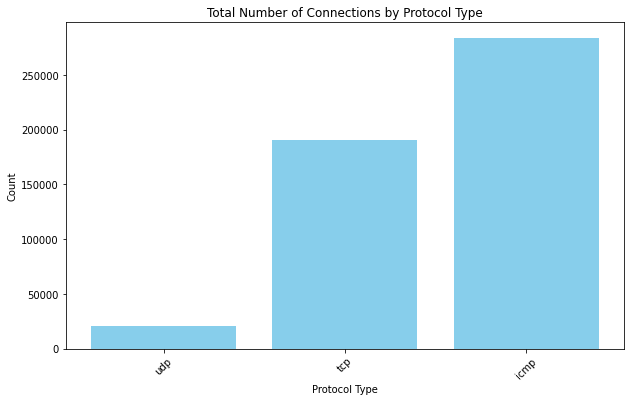

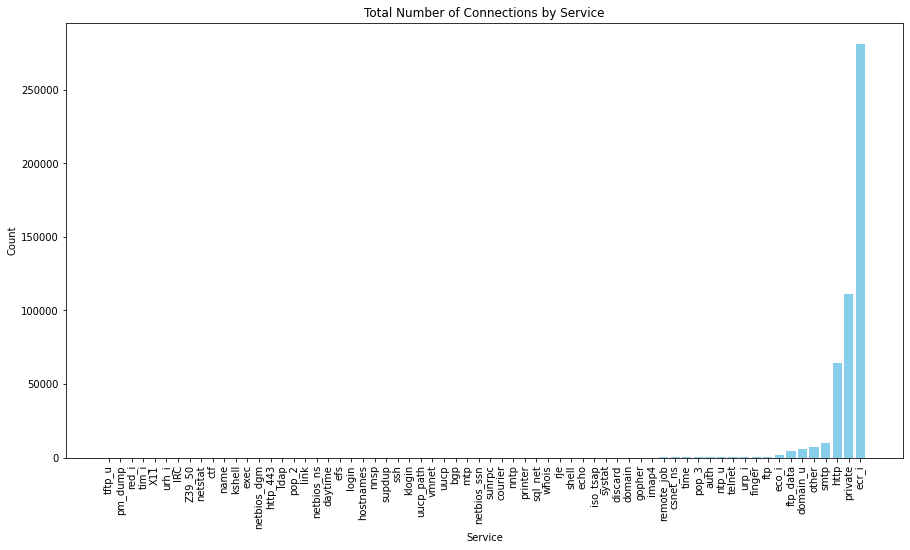

In [0]:
from matplotlib import pyplot as plt

# Convert Spark DataFrame to Pandas DataFrame for plotting
protocol_count_pd = protocol_count_df.toPandas()
service_count_pd = service_count_df.toPandas()

plt.figure(figsize=(10, 6))
plt.bar(protocol_count_pd["protocol_type"], protocol_count_pd["count"], color='skyblue')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.title('Total Number of Connections by Protocol Type')
plt.xticks(rotation=45)
plt.show()

# Plot the bar graph for service
plt.figure(figsize=(15, 8))
plt.bar(service_count_pd["service"], service_count_pd["count"], color='skyblue')
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Total Number of Connections by Service')
plt.xticks(rotation=90)
plt.show()

Part A - Q7. Do a further exploratory data analysis, including other columns of this dataset and plot graphs. Plot at least 3 different charts and explain them.

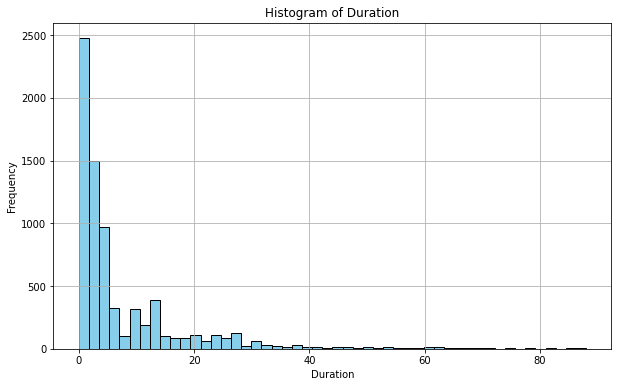

In [0]:
# Plot a histogram of the 'duration' column
import numpy as np

data_df = new_df.withColumn("duration", col("duration").cast("int"))
duration_pd = data_df.select("duration").toPandas()
non_zero_duration_pd = duration_pd[duration_pd["duration"] > 0]
max_duration = non_zero_duration_pd["duration"].quantile(0.6)


plt.figure(figsize=(10, 6))
plt.hist(non_zero_duration_pd["duration"], bins=50, range=(0, max_duration), color='skyblue', edgecolor='black')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of Duration')
plt.grid(True)
plt.show()

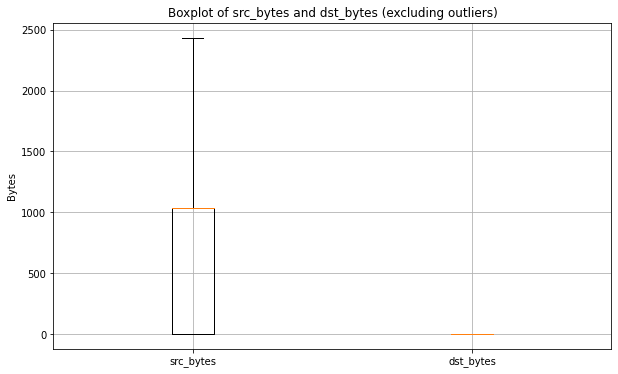

In [0]:
# Convert columns to Pandas DataFrame for plotting
new_df = new_df.withColumn("src_bytes", col("src_bytes").cast("int"))
new_df = new_df.withColumn("dst_bytes", col("dst_bytes").cast("int"))
bytes_pd = new_df.select("src_bytes", "dst_bytes").toPandas()

Q1_src = bytes_pd["src_bytes"].quantile(0.25)
Q3_src = bytes_pd["src_bytes"].quantile(0.75)
IQR_src = Q3_src - Q1_src

Q1_dst = bytes_pd["dst_bytes"].quantile(0.25)
Q3_dst = bytes_pd["dst_bytes"].quantile(0.75)
IQR_dst = Q3_dst - Q1_dst

# Define bounds for non-outliers
lower_bound_src = Q1_src - 1.5 * IQR_src
upper_bound_src = Q3_src + 1.5 * IQR_src

lower_bound_dst = Q1_dst - 1.5 * IQR_dst
upper_bound_dst = Q3_dst + 1.5 * IQR_dst

# Filter out outliers
filtered_bytes_pd = bytes_pd[(bytes_pd["src_bytes"] >= lower_bound_src) & (bytes_pd["src_bytes"] <= upper_bound_src) &
                             (bytes_pd["dst_bytes"] >= lower_bound_dst) & (bytes_pd["dst_bytes"] <= upper_bound_dst)]


plt.figure(figsize=(10, 6))
plt.boxplot([filtered_bytes_pd["src_bytes"], filtered_bytes_pd["dst_bytes"]], labels=['src_bytes', 'dst_bytes'])
plt.ylabel('Bytes')
plt.title('Boxplot of src_bytes and dst_bytes (excluding outliers)')
plt.grid(True)
plt.show()

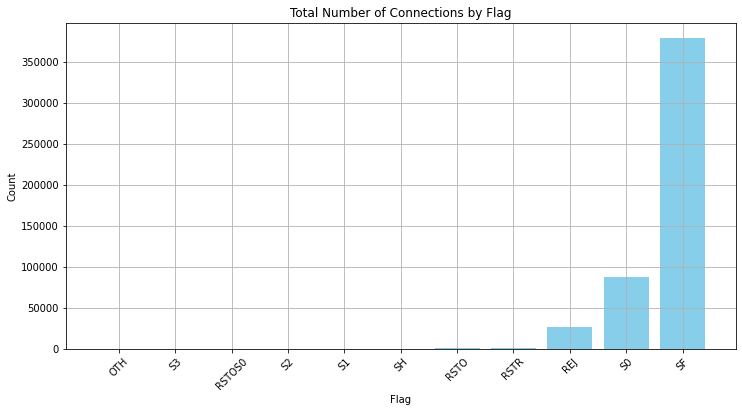

In [0]:
# Group by flag and count the occurrences
flag_count_df = new_df.groupBy("flag").count().orderBy("count")

# Convert to Pandas DataFrame for plotting
flag_count_pd = flag_count_df.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(flag_count_pd["flag"], flag_count_pd["count"], color='skyblue')
plt.xlabel('Flag')
plt.ylabel('Count')
plt.title('Total Number of Connections by Flag')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Part A - Q8. Look at the label column where label == ‘normal’. Now create a new label column where you have a label == ‘normal’ and everything else is considered as an ‘attack’. Split your data (train/test) and based on your new label column now build a simple machine learning model for intrusion detection (you can use few selected columns for your model out of all). Explain which algorithm you have selected and why. Show the results with some success metrics.

In [0]:
from pyspark.sql.functions import when, col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, IndexToString
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Create a new label column
data_df = new_df.withColumn("new_label", when(new_df.label == "normal.", "normal").otherwise("attack"))
data_df = data_df.withColumn("duration", col("duration").cast("int"))
data_df = data_df.withColumn("src_bytes", col("src_bytes").cast("int"))
data_df = data_df.withColumn("dst_bytes", col("dst_bytes").cast("int"))

# Split the data into train and test sets
train_df, test_df = data_df.randomSplit([0.7, 0.3], seed=42)

# Select the columns to be used in the model
selected_columns = ["duration", "protocol_type", "service", "src_bytes", "dst_bytes", "flag", "new_label"]
train_df = train_df.select(*selected_columns)
test_df = test_df.select(*selected_columns)

# Index and encode categorical columns
indexers = [StringIndexer(inputCol=column, outputCol=column+"_index") for column in ["protocol_type", "service", "flag"]]
encoders = [OneHotEncoder(inputCol=column+"_index", outputCol=column+"_vec") for column in ["protocol_type", "service", "flag"]]

# Assemble all features into a single vector
assembler = VectorAssembler(
    inputCols=["duration", "src_bytes", "dst_bytes", "protocol_type_vec", "service_vec", "flag_vec"],
    outputCol="features"
)

# Create a logistic regression model
lr = LogisticRegression(labelCol="new_label_index", featuresCol="features", maxIter=10)

# Index the label column
label_indexer = StringIndexer(inputCol="new_label", outputCol="new_label_index")

# Convert indexed predictions back to original labels
label_converter = IndexToString(inputCol="prediction", outputCol="predicted_label", labels=["normal", "attack"])

# Create a pipeline to execute all steps
pipeline = Pipeline(stages=indexers + encoders + [assembler, label_indexer, lr, label_converter])

# Train the model
model = pipeline.fit(train_df)

predictions = model.transform(test_df)

# Evaluate the model using accuracy and F1 score
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="new_label_index", predictionCol="prediction", metricName="accuracy")

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="new_label_index", predictionCol="prediction", metricName="f1")

accuracy = evaluator_accuracy.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1_score}")

Accuracy: 0.9893520952111385
F1 Score: 0.9894231737737884
